# Assignment: Value Function Approximation for the Lunar Lander Problem using Tile Coding

Name: Chris Hirschbrich


Learning Goals:
* Implement RL with linear approximation and tile coding.
* Experiment with approximation for a small problem with continuous state space.
* Discuss the effect of reward engineering and reward shaping.

AI tool usage:
* You **can use AI** to help you debug and write small pieces of code.

Instruction: Complete this notebook, run all cells, convert to HTML and upload to Canvas.

## Introduction

You want to use Monte Carlo control to learn a good policy for the Lunar Lander environment. The Lunar Lander environment allows sample access, but in this example you cannot choose the starting states for sampling  episode. This means you cannot use exploring starts and you have to implement Monte Carlo control with an $\epsilon$-soft policy to guarantee exploration.

## Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [36]:
import numpy as np
np.set_printoptions(precision=2)

In [37]:

# Modified Gym-classics Installation
!git clone https://github.com/mhahsler/gym-classics.git
!cd gym-classics;git pull
!cd gym-classics; pip install -e .

import gymnasium as gym
import sys
sys.path.insert(0, "/content/gym-classics")
import gym_classics
print("Imported via sys.path:", gym_classics.__file__)
gym_classics.register('gymnasium')

fatal: destination path 'gym-classics' already exists and is not an empty directory.
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 12 (delta 9), reused 9 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (12/12), 828 bytes | 414.00 KiB/s, done.
From https://github.com/mhahsler/gym-classics
   9888648..bdf6836  main       -> origin/main
Updating 9888648..bdf6836
Fast-forward
 .../{termporal_differnce_learning.py => temporal_difference_learning.py}  | 0
 1 file changed, 0 insertions(+), 0 deletions(-)
 rename gym_classics/algorithms/{termporal_differnce_learning.py => temporal_difference_learning.py} (100%)
Obtaining file:///content/gym-classics
  Preparing metadata (setup.py) ... done
  Attempting uninstall: gym-classics
    Found existing installation: gym-classics 1.0.0+internal.rev1
    Uninstalling gym-classics-1.0.0+internal.rev1:
      Successfully uninstalled gym-classics-1

/content/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


In [38]:
import sys

# Ensure the gym-classics path is included for imports
if "/content/gym-classics" not in sys.path:
    sys.path.insert(0, "/content/gym-classics")


In [39]:
# download if missing
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

download("gymnasium_display_recorder.py",
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/common/")


## Task 1: Implement Tile Coding

The Lunar Lander problem is difficult, start with the simple [L-Maze](https://colab.research.google.com/github/mhahsler/Introduction_to_Reinforcement_Learning/blob/master/Approximation/Fourier_basis_features_L_maze.ipynb) and replace
the Fourier basis features with tile coding (see slides/textbook, and this [example](http://incompleteideas.net/tiles/tiles3.html)). Experiment with different number of tilings, tile sizes and learning rates to get a good result.

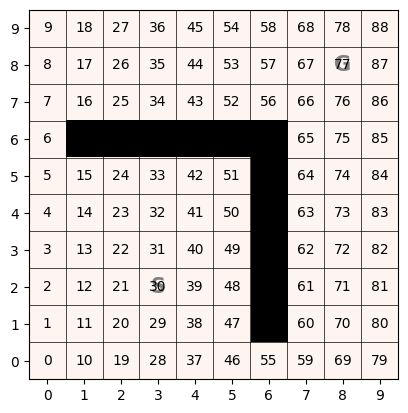

In [71]:
### Your code
gym_env = gym.make('LMaze-v0')

env = gym_env.unwrapped
env.image()

In [72]:
from gym_classics.algorithms.linear_approximation import semi_gradient_Sarsa_0, state_features, q_hat
from gym_classics.algorithms.policy import greedy_policy

# helper to visualize the learned policy and value function
def plot_w(w, title=None):
    Q = np.array([[q_hat(s, a, w) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    V = np.max(Q, axis=1)
    pol = np.argmax(Q, axis=1)
    env.image(V, policy=pol, title=title, clim=(-1,1))
    return Q, V, pol

In [73]:
def create_tile_coding(min_vals, max_vals, num_tilings, tile_size):
    min_vals  = np.array(min_vals, dtype=float)
    max_vals  = np.array(max_vals, dtype=float)
    tile_size = np.broadcast_to(np.array(tile_size, dtype=float), min_vals.shape).copy()
    dims      = len(min_vals)

    # How many tiles span each dimension (add one extra to handle boundary)
    n_tiles_per_dim = np.ceil((max_vals - min_vals) / tile_size).astype(int) + 1
    tiles_per_tiling = int(np.prod(n_tiles_per_dim))

    # +1 for a constant bias feature expected by gym_classics linear_approximation.
    n_features = 1 + int(num_tilings * tiles_per_tiling)

    # Pre-compute per-tiling offsets (each tiling is shifted by a fraction of the tile size)
    offsets = np.array([
        [(t * tile_size[d] / num_tilings) for d in range(dims)]
        for t in range(num_tilings)
    ])  # shape: (num_tilings, dims)

    def transform(s):
        s = np.array(s, dtype=float)
        features = np.zeros(n_features, dtype=float)
        features[0] = 1.0

        for t in range(num_tilings):
            shifted = s - min_vals + offsets[t]       # shift state within tiling grid
            tile_idx = np.floor(shifted / tile_size).astype(int)
            tile_idx = np.clip(tile_idx, 0, n_tiles_per_dim - 1)
            # Compute flat index for this tile within its tiling
            flat = 0
            for d in range(dims):
                flat = flat * n_tiles_per_dim[d] + tile_idx[d]
            features[1 + t * tiles_per_tiling + flat] = 1.0
        return features

    return transform, n_features

In [74]:
# Parameters to experiment with
NUM_TILINGS = 8
TILE_SIZE   = 2.0   # in grid units

trans_tc, n_feat = create_tile_coding(
    min_vals    = [0, 0],
    max_vals    = env.dims,
    num_tilings = NUM_TILINGS,
    tile_size   = TILE_SIZE
)

print(f'Grid size        : {env.dims}')
print(f'Num tilings      : {NUM_TILINGS}')
print(f'Tile size        : {TILE_SIZE}')
print(f'Total features   : {n_feat}')
print(f'Active per state : {NUM_TILINGS + 1}  ({NUM_TILINGS} tiles + bias)')
print()
sample = trans_tc((1, 1))
print(f'Feature vector for state (1,1): {sample}')
print(f'Non-zero indices: {np.where(sample)[0]}')

Grid size        : (10, 10)
Num tilings      : 8
Tile size        : 2.0
Total features   : 289
Active per state : 9  (8 tiles + bias)

Feature vector for state (1,1): [1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [75]:
import gym_classics.algorithms.linear_approximation as la

def state_features(s):
    return trans_tc(env.decode(s))

la.state_features = state_features


Semi-Gradient SARSA(0): 100%|██████████| 5000/5000 [01:30<00:00, 55.16it/s]


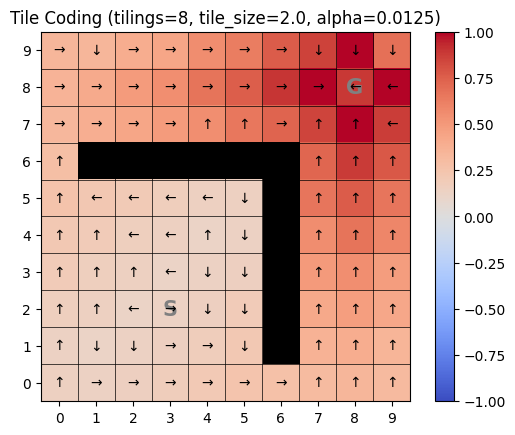

In [76]:
# Learning rate heuristic: alpha = 1 / num_tilings gives stable learning
ALPHA = 1.0 / (10 * NUM_TILINGS)

w = semi_gradient_Sarsa_0(
    env,
    n                  = 5000,
    epsilon            = 0.3,
    alpha              = ALPHA,
    gamma              = 0.9,
    max_episode_length = 500,
    verbose            = False
)
Q, V, pol = plot_w(w, title=f'Tile Coding (tilings={NUM_TILINGS}, tile_size={TILE_SIZE}, alpha={ALPHA:.4f})')

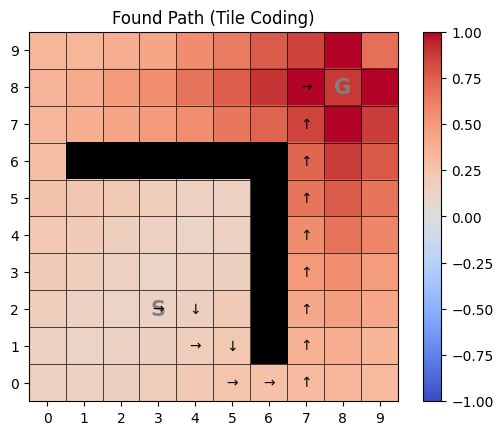

In [77]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol, max_len=1000)
env.image(V, policy=pol, episode=path, title='Found Path (Tile Coding)', clim=(-1,1))

In [78]:
from gym_classics.algorithms.dynamic_programming import value_iteration

V_true = value_iteration(env, discount=0.9)

def MSVE(V, V_true):
    """Root-mean-squared value error (excluding terminal states)."""
    return np.sqrt(np.mean((V - V_true)**2))

Value Iteration: 17it [00:00, 274.35it/s]


In [79]:
results = []

param_grid = [
    (num_tilings, tile_size)
    for num_tilings in [4, 8]
    for tile_size   in [1.0, 1.5, 2.0]
]

for num_tilings, tile_size in param_grid:
    alpha = 1 / (10 * num_tilings)

    trans, _ = create_tile_coding(
        min_vals    = [0, 0],
        max_vals    = env.dims,
        num_tilings = num_tilings,
        tile_size   = tile_size
    )

    def state_features(s):
        return trans(env.decode(s))
    la.state_features = state_features

    w = semi_gradient_Sarsa_0(
        env, n=5000, epsilon=0.3, alpha=alpha,
        gamma=0.9, max_episode_length=1000, verbose=False
    )

    Q_out = np.array([[q_hat(s, a, w) for a in range(env.action_space.n)]
                      for s in range(env.observation_space.n)])
    V_learned = np.max(Q_out, axis=1)

    msve = MSVE(V_learned[:-2], V_true[:-2])
    results.append(dict(num_tilings=num_tilings, tile_size=tile_size,
                       alpha=alpha, msve=msve))
    print(f'tilings={num_tilings:2d}, tile_size={tile_size:.1f}, '
          f'alpha={alpha:.4f}  ->  MSVE = {msve:.4f}')

Semi-Gradient SARSA(0): 100%|██████████| 5000/5000 [01:14<00:00, 67.49it/s]


tilings= 4, tile_size=1.0, alpha=0.0250  ->  MSVE = 0.1178


Semi-Gradient SARSA(0): 100%|██████████| 5000/5000 [00:55<00:00, 90.47it/s]


tilings= 4, tile_size=1.5, alpha=0.0250  ->  MSVE = 0.1151


Semi-Gradient SARSA(0): 100%|██████████| 5000/5000 [00:48<00:00, 102.60it/s]


...

tilings= 8, tile_size=1.0, alpha=0.0125  ->  MSVE = 0.1470


Semi-Gradient SARSA(0): 100%|██████████| 5000/5000 [01:41<00:00, 49.29it/s]


tilings= 8, tile_size=1.5, alpha=0.0125  ->  MSVE = 0.1200


Semi-Gradient SARSA(0): 100%|██████████| 5000/5000 [01:31<00:00, 54.92it/s]

tilings= 8, tile_size=2.0, alpha=0.0125  ->  MSVE = 0.1178


What were the most important things you learned.

After doing many experiments, I learned several things, specifically about the interaction of learning rate in tile coding, and the number of tilings and their size.

Impact of Learning Rate ($\alpha$)
- I found that setting alpha too high can cause the model to overshoot the optimal policy. This made the value function updates more aggressive than intended and led to instability between tests. The outcome was never the same twice, where it would sometimes find a policy, and other times go the opposite direction. Tuning alpha was necessary for the model to converge to the optimal policy.
  - Something I considered when tuning parameters was the tradeoff between stability and speed, where the lower learning rate would be more stable but take longer to trade. I decided that getting convergence to the optimal policy was a nonnegotiable, and considering the size of the problem, this did not take too long.

Tile Size and Number
- I noticed that when training the model I had set the tile size to 1, which slowed down training significantly and led to a useless policy. Small tiles create a higher dimensional feature space that requires the agent to visit many more specific cells to actually find something useful.
- Using larger tiles allowed for better generalization as a single update affects a wider area. I also discovered that if the tiles are too large, the model loses the precision needed to make some accurate updates.
- I found that running the model with 8 tiles with a size of 2 is the most effective configuration. There was enough overlap in this problem by using 8 tiles where they were general enough to update many states and detailed enough to learn the correct policy.

## Task 2: Try to Use the Algorithm for the Lunar Lander Environment

Apply your tile coding to the [Lunar Lander Environment we have used in the introduction](https://colab.research.google.com/github/mhahsler/Introduction_to_Reinforcement_Learning/blob/master/Intro/lunar_lander.ipynb). The state space is high-dimensional and continuous. Tile coding is a very popular choice to deal with continuous state spaces.

In [42]:
# Imports and setup
%pip install swig
%pip install pyvirtualdisplay
%pip install gymnasium[box2d,other]



In [43]:
# Code borrowed from Dr. Hahsler:

def query_environment(name):
    env = gym.make(name)
    print(f"Action Space: {env.action_space}")
    print(f"Observation Space: {env.observation_space}")
    print(f"Max Episode Steps: {env.spec.max_episode_steps}")
    print(f"Nondeterministic: {env.spec.nondeterministic}")
    print(f"Reward Threshold: {env.spec.reward_threshold}")
    env.close()

query_environment("LunarLander-v3")

def run_episode(agent_function, env, max_steps=1000, verbose = True, render = True):
    """Run one episode in the environment using the provided agent."""

    # Reset the environment to generate the first observation (use seed=42 in reset to get reproducible results)
    observation, info = env.reset()

    Return = 0
    # Run one episode
    for i in range(max_steps):
        # call the agent function to select an action
        action = agent_function(observation)

        # step: execute an action in the environment
        observation_prime, reward, terminated, truncated, info = env.step(action)

        if verbose:
            print (f"Step {i+1}: Obs {np.round(observation, 1)} -> Action {action} - > Reward {np.round(reward,1)}, Obs' {np.round(observation_prime,1)}")

        observation = observation_prime
        Return += reward

        # Render the environment
        if render:
            env.render()

        if terminated:
            break

    success = reward == 100.0

    if verbose:
        print(f"Episode Return: {Return} (success: {success})")

    return Return, success

Action Space: Discrete(4)
Observation Space: Box([ -2.5   -2.5  -10.   -10.    -6.28 -10.    -0.    -0.  ], [ 2.5   2.5  10.   10.    6.28 10.    1.    1.  ], (8,), float32)
Max Episode Steps: 1000
Nondeterministic: False
Reward Threshold: 200


In [44]:
def random_agent_function(observation):
    """A random agent that selects actions uniformly at random. It ignores the observation."""
    return np.random.choice([0, 1, 2, 3], p=[0.25, 0.25, 0.25, 0.25])

In [45]:
from gymnasium_display_recorder import VideoWrapper, show

env = gym.make('LunarLander-v3', render_mode="rgb_array")
env_record = VideoWrapper(env, 'LL1', render_fps=30)

run_episode(random_agent_function, env_record, verbose=False)

show(env_record)

Videos already exist, I remove them first!


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Showing: ./videos/video_LL1-episode-0.mp4


In [46]:
# Create sensors for the agent to use as input
from enum import Enum

class Act(Enum):
    LEFT = 1
    RIGHT = 3
    MAIN = 2
    NO_OP = 0

class Obs(Enum):
    X = 0
    Y = 1
    VX = 2
    VY = 3
    ANGLE = 4
    ANGULAR_VELOCITY = 5
    LEFT_LEG_CONTACT = 6
    RIGHT_LEG_CONTACT = 7

In [69]:
# Tile coding + one-hot features for all 8 LunarLander observations.
NUM_TILINGS_LL = 16
TILES_PER_DIM = np.array([8, 8, 8, 8, 12, 12], dtype=int)
IHT_SIZE = 8192
N_ACTIONS = 4

# Practical clipping ranges for LunarLander observations.
LL_LOW  = np.array([-2.5, -2.5, -5.0, -5.0, -np.pi, -5, 0, 0], dtype = float)
LL_HIGH = np.array([2.5, 2.5, 5.0, 5.0, np.pi, 5, 1, 1], dtype = float)

# Extra 4 dims are one-hot for leg-contact states: 00, 01, 10, 11.
LANDER_FEATURE_DIM = IHT_SIZE + 4
lander_w = np.zeros((N_ACTIONS, LANDER_FEATURE_DIM), dtype=float)


def lander_features(observation):
    """Tile-code 6 continuous dims + 1-hot encode the two contact bits."""
    obs = np.asarray(observation, dtype=float)

    cont = np.clip(obs[:6], LL_LOW[:6], LL_HIGH[:6])
    ratio = (cont - LL_LOW[:6]) / (LL_HIGH[:6] - LL_LOW[:6] + 1e-12)
    scaled = ratio * (TILES_PER_DIM - 1)

    feat = np.zeros(LANDER_FEATURE_DIM, dtype=float)

    # Sparse tile-coding activations (one active tile per tiling).
    for t in range(NUM_TILINGS_LL):
        shifted = np.floor(scaled + (t / NUM_TILINGS_LL)).astype(int)
        key = (t, *shifted, int(obs[6] > 0.5), int(obs[7] > 0.5))
        idx = hash(key) % IHT_SIZE
        feat[idx] = 1.0

    # One-hot encoding of contact pair.
    contact_state = int(obs[6] > 0.5) * 2 + int(obs[7] > 0.5)
    feat[IHT_SIZE + contact_state] = 1.0

    return feat


def q_values_lander(observation):
    feat = lander_features(observation)
    return lander_w @ feat


def tile_coding_lander(observation):
    """Greedy policy from learned linear action-values."""
    return int(np.argmax(q_values_lander(observation)))


def train_tile_coding_lander(
    env,
    num_episodes=400,
    alpha=0.01,
    gamma=0.99,
    epsilon_start=0.20,
    epsilon_end=0.02,
    epsilon_decay=0.995,
    verbose=False
):
    """Semi-gradient SARSA(0) with tile-coded + one-hot features."""
    global lander_w
    lander_w = np.zeros((N_ACTIONS, LANDER_FEATURE_DIM), dtype=float)

    returns = []
    episode_lengths = []
    epsilon = epsilon_start

    for ep in range(num_episodes):
        obs, _ = env.reset()
        feat = lander_features(obs)

        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(lander_w @ feat))

        done = False
        G = 0.0
        step_count = 0

        while not done:
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            step_count += 1

            # I give a reward to teach the agent to sit still once landed
            left_contact = obs[Obs.LEFT_LEG_CONTACT.value] > 0.5
            right_contact = obs[Obs.RIGHT_LEG_CONTACT.value] > 0.5
            vx_stable = abs(obs[Obs.VX.value]) < 0.1
            vy_stable = abs(obs[Obs.VY.value]) < 0.1
            ang_vel_stable = abs(obs[Obs.ANGULAR_VELOCITY.value]) < 0.1
            # Bonus for choosing NO_OP when safely landed
            if (left_contact and right_contact and vx_stable and vy_stable and ang_vel_stable):
              if action == Act.NO_OP.value:
                reward += 0.1

            G += reward

            q_sa = np.dot(lander_w[action], feat)

            if done:
                target = reward
                td_error = target - q_sa
                lander_w[action] += alpha * td_error * feat
            else:
                next_feat = lander_features(next_obs)
                if np.random.rand() < epsilon:
                    next_action = env.action_space.sample()
                else:
                    next_action = int(np.argmax(lander_w @ next_feat))

                target = reward + gamma * np.dot(lander_w[next_action], next_feat)
                td_error = target - q_sa
                lander_w[action] += alpha * td_error * feat

                obs, feat, action = next_obs, next_feat, next_action

        returns.append(G)
        episode_lengths.append(step_count)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (verbose):
          if (ep + 1) % 50 == 0:
              avg_50 = np.mean(returns[-50:])
              avg_len_50 = np.mean(episode_lengths[-50:])
              print(f"Episode {ep + 1:4d} | avg return (last 50): {avg_50:8.2f} | avg length (last 50): {avg_len_50:8.1f} | epsilon: {epsilon:.3f}")

    return returns

In [60]:
# Clean videos folder
# I used this mostly for debugging in VSCode
for file in os.listdir('videos'):
    os.remove(os.path.join('videos', file))

Episode   50 | avg return (last 50):  -200.89 | avg length (last 50):    146.2 | epsilon: 0.285
Episode  100 | avg return (last 50):  -214.20 | avg length (last 50):    185.2 | epsilon: 0.271
Episode  150 | avg return (last 50):  -149.00 | avg length (last 50):    266.0 | epsilon: 0.258
Episode  200 | avg return (last 50):  -110.62 | avg length (last 50):    357.8 | epsilon: 0.246
Episode  250 | avg return (last 50):  -147.30 | avg length (last 50):    315.6 | epsilon: 0.234
Episode  300 | avg return (last 50):   -77.76 | avg length (last 50):    372.2 | epsilon: 0.222
Episode  350 | avg return (last 50):   -72.32 | avg length (last 50):    498.8 | epsilon: 0.211
Episode  400 | avg return (last 50):   -52.79 | avg length (last 50):    610.8 | epsilon: 0.201
Episode  450 | avg return (last 50):   -35.81 | avg length (last 50):    752.0 | epsilon: 0.191
Episode  500 | avg return (last 50):   -14.07 | avg length (last 50):    823.4 | epsilon: 0.182
Episode  550 | avg return (last 50):   -

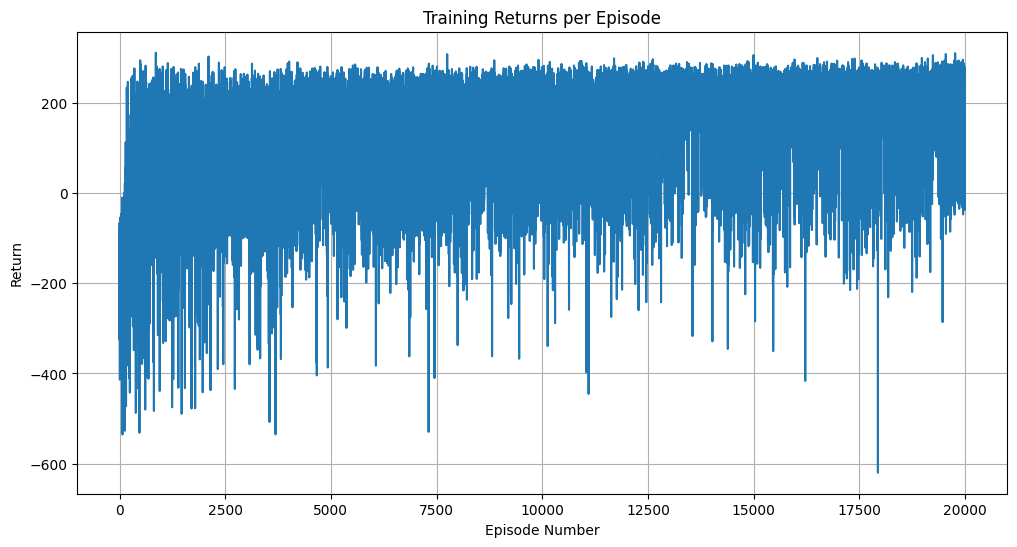

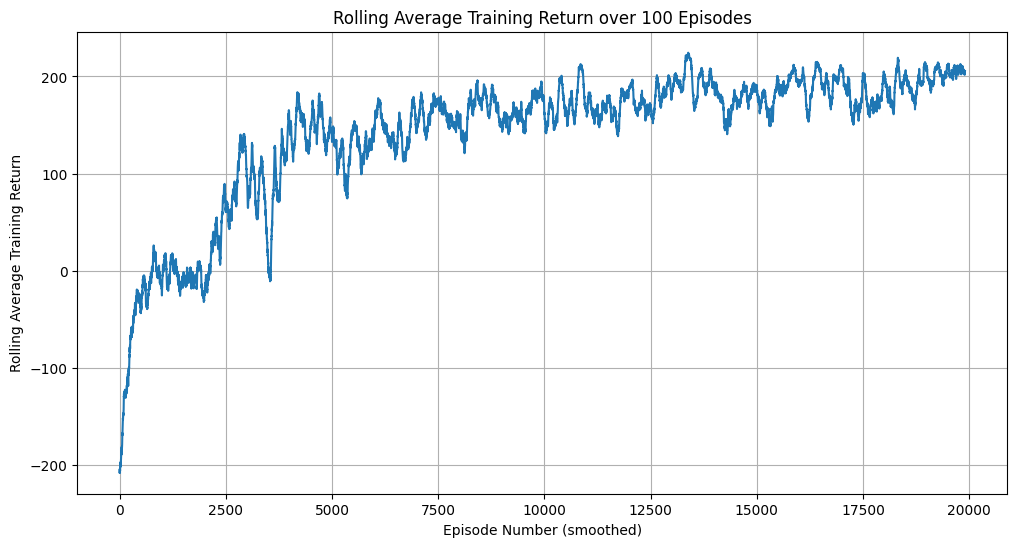


Running 3 evaluation episodes with the trained agent...
Evaluation Episode 1: Return = 216.39 (success: True)
Showing: ./videos/video_LL1-episode-104.mp4


Evaluation Episode 2: Return = 225.07 (success: True)
Showing: ./videos/video_LL1-episode-105.mp4


Evaluation Episode 3: Return = 224.05 (success: True)
Showing: ./videos/video_LL1-episode-106.mp4



Completed 3 evaluation episodes.
Average return over 3 evaluation episodes: 221.84


In [ ]:
# Train on non-rendering env, then evaluate in recorded env.
env_train = gym.make('LunarLander-v3')
training_returns = train_tile_coding_lander(
    env_train,
    num_episodes=20000,
    alpha= 1.0 / (10 * NUM_TILINGS_LL),
    gamma=0.99,
    epsilon_start=0.30,
    epsilon_end=0.01,
    epsilon_decay=0.999,
    verbose=True
)
env_train.close()

print(f"Training complete. Final 50-episode average return (training): {np.mean(training_returns[-50:]):.2f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(training_returns)
plt.xlabel('Episode Number')
plt.ylabel('Return')
plt.title('Training Returns per Episode')
plt.grid(True)
plt.show()

# Plot a rolling average to smooth out the curve for training returns
window_size = 100 # Using a larger window for training plots
if len(training_returns) >= window_size:
    rolling_average_training = np.convolve(training_returns, np.ones(window_size)/window_size, mode='valid')
    plt.figure(figsize=(12, 6))
    plt.plot(rolling_average_training)
    plt.xlabel('Episode Number (smoothed)')
    plt.ylabel('Rolling Average Training Return')
    plt.title(f'Rolling Average Training Return over {window_size} Episodes')
    plt.grid(True)
    plt.show()
else:
    print(f"Not enough training episodes ({len(training_returns)}) to plot rolling average with window size {window_size}.")


# Evaluations
evaluation_returns = []
num_evaluation_episodes = 3

print(f"\nRunning {num_evaluation_episodes} evaluation episodes with the trained agent...")
for i in range(num_evaluation_episodes):
    render_current_episode = True

    episode_return, success = run_episode(tile_coding_lander, env_record, verbose=False, render=render_current_episode)
    evaluation_returns.append(episode_return)

    print(f"Evaluation Episode {i+1}: Return = {episode_return:.2f} (success: {success})")
    show(env_record)

print(f"\nCompleted {num_evaluation_episodes} evaluation episodes.")
print(f"Average return over {num_evaluation_episodes} evaluation episodes: {np.mean(evaluation_returns):.2f}")

Run and document experiments that show how well the approach works.


Running 100 evaluation episodes with the trained agent...
  Evaluation Episode 10/100: Return = 237.13 (success: True)
  Evaluation Episode 20/100: Return = 265.78 (success: True)
  Evaluation Episode 30/100: Return = 169.27 (success: True)
  Evaluation Episode 40/100: Return = 205.98 (success: True)
  Evaluation Episode 50/100: Return = 264.48 (success: True)
  Evaluation Episode 60/100: Return = 223.58 (success: True)
  Evaluation Episode 70/100: Return = 225.18 (success: True)
  Evaluation Episode 80/100: Return = 176.87 (success: True)
  Evaluation Episode 90/100: Return = 211.11 (success: True)
  Evaluation Episode 100/100: Return = 163.57 (success: True)

Completed 100 evaluation episodes.
Success Rate over 100 episodes: 91.00%
Average Return over 100 episodes: 198.83


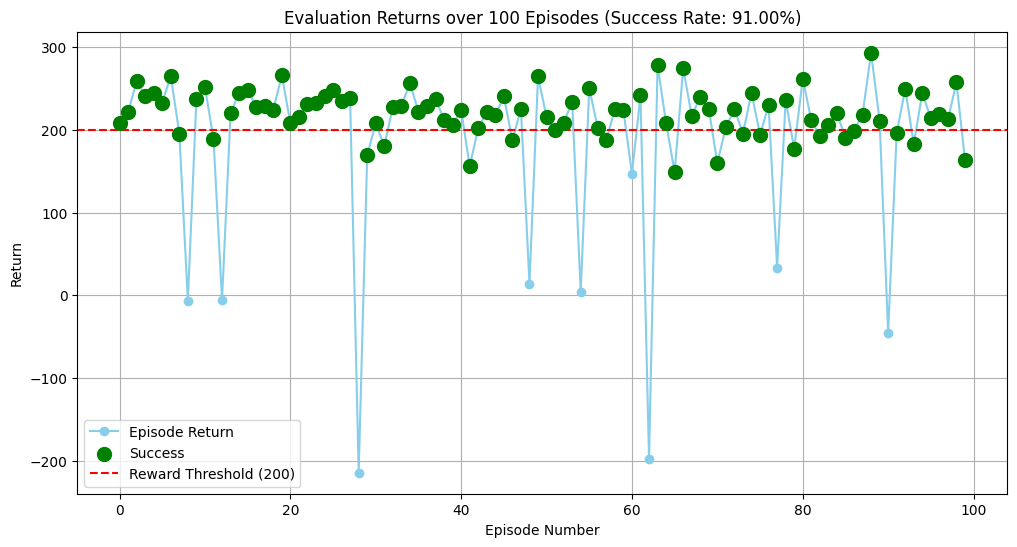

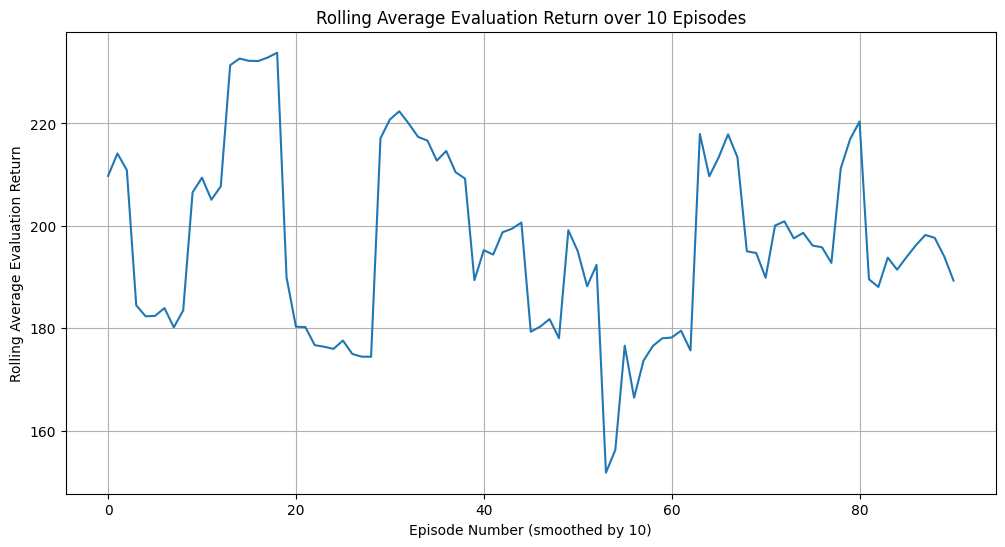

In [56]:
import matplotlib.pyplot as plt

evaluation_returns_100 = []
evaluation_successes_100 = []
num_evaluation_episodes = 100

print(f"\nRunning {num_evaluation_episodes} evaluation episodes with the trained agent...")
for i in range(num_evaluation_episodes):
    # Set render=False to speed up evaluation, set to True if you want to see individual episodes
    episode_return, success = run_episode(tile_coding_lander, env_record, verbose=False, render=False)
    evaluation_returns_100.append(episode_return)
    evaluation_successes_100.append(success)

    if (i + 1) % 10 == 0:
        print(f"  Evaluation Episode {i+1}/{num_evaluation_episodes}: Return = {episode_return:.2f} (success: {success})")

success_count = np.sum(evaluation_successes_100)
success_rate = (success_count / num_evaluation_episodes) * 100

print(f"\nCompleted {num_evaluation_episodes} evaluation episodes.")
print(f"Success Rate over {num_evaluation_episodes} episodes: {success_rate:.2f}%")
print(f"Average Return over {num_evaluation_episodes} episodes: {np.mean(evaluation_returns_100):.2f}")

# Plotting the returns and indicating successes
plt.figure(figsize=(12, 6))
plt.plot(evaluation_returns_100, marker='o', linestyle='-', color='skyblue', label='Episode Return')
success_indices = np.where(evaluation_successes_100)[0]
plt.scatter(success_indices, np.array(evaluation_returns_100)[success_indices], color='green', s=100, label='Success', zorder=5)
plt.xlabel('Episode Number')
plt.ylabel('Return')
plt.title(f'Evaluation Returns over {num_evaluation_episodes} Episodes (Success Rate: {success_rate:.2f}%)')
plt.axhline(y=200, color='red', linestyle='--', label='Reward Threshold (200)')
plt.grid(True)
plt.legend()
plt.show()

# Plot rolling average of returns for these evaluation episodes
window_size = 10
if len(evaluation_returns_100) >= window_size:
    rolling_average_eval = np.convolve(evaluation_returns_100, np.ones(window_size)/window_size, mode='valid')
    plt.figure(figsize=(12, 6))
    plt.plot(rolling_average_eval)
    plt.xlabel(f'Episode Number (smoothed by {window_size})')
    plt.ylabel('Rolling Average Evaluation Return')
    plt.title(f'Rolling Average Evaluation Return over {window_size} Episodes')
    plt.grid(True)
    plt.show()
else:
    print(f"Not enough evaluation episodes ({len(evaluation_returns_100)}) to plot rolling average with window size {window_size}.")


## Task 3: Discussion

Discuss what worked and what did not work.

For the Lunar Lander, I had many issues selecting hyperparameters and the learning structure itself.

**(1)** The first problem I ran into was that the lander stalled, choosing not to end the episode.
- My early testing revealed a huge flaw with my current implementation and its interaction with the native reward structure. The lander would touch down on an uneven surface safely, where both legs touched the ground and no obvious crashing, and become stuck. Instead of the episode ending due to a crash or a safe touchdown, it would be stuck firing its engines indefinitely to maintain balance or attempt to move.
- This behavior led to a decrease in average success rate and reward because the agent accumulated high negative penalties for constantly firing its left or right engine.
- More importantly, it dramatically increased learning time, sometimes ranging for 2x or 3x time used. Each time this ocurred, the agent would use all 1000 allowed steps before the episode was terminated, wasting computational resources on a state that should be considered a simple land.

To solve this problem, I made an edit to the reward structure.
- To solve the stuck engine, I included a rule that rewarded the agent if it was in a "Landed safely" and immediately chose NO_OP, ending the episode. I believe this is okay since the episode would be a failure if it crashed, but this is not the case.
- This change ensured that if the episode was going to fail, it failed quickly, or if the state was good, it actually ended and applied the full reward. This allowed the agent to start a new episode sooner and effectively learned that using the engines in a terminal state doesn't make sense.

**(2)** The second problem was with tuning hyperparameters moving from the 2D maze to the 8D lunar lander, it was not as simple as copying the tilings over. I had to experiment extensively to achieve a stable policy.
- Learning Rate ($\alpha$): Balanced using the formula 1.0 / (10.0 * NUM_TILINGS). This ensured steady improvement with respect to the number of tilings used without overshooting.
- Exploration ($\epsilon$): Adjusted to ensure the agent explored early, but focused on its learned policy as training progressed. I found that instead of a constant exploration, decreasing it slowly over the first 3300 episodes gave it enough time to explore different paths, and then used the rest of the episodes to refine its strategy.
- Tile Coding: Fine-tuning the tile size and number of bins was difficult as I had to find a good amount of each that supported this more complex task. Using 16 tiles with 8-12 bins led to a nice convergence.
- Episode count: Beginning this project, I started with a very low episode count, around 500. I very quickly found this was way too low. I increased it to 5000, and found the same. I continued doubling until 20000 episodes, which I found some convergence with the parameters untuned, which showed promise. To be sure, I continued increasing to 25k and found this changed little and was taking too long. I focused more on the other parameters and found convergence resulting in a 91% validation.


A simple reward structure for the Lunar Lander problem would be +100 for landing and -100 for crashing. However,
the [reward structure for the Lunar Lander](https://gymnasium.farama.org/environments/box2d/lunar_lander/) is more complicated. Why is that? Read the introduction for [Comprehensive Overview of Reward Engineering and Shaping in Advancing Reinforcement Learning Applications](https://arxiv.org/abs/2408.10215) and try to explain why this reward structure was chosen.

A simple reward structure that we used for our rule-based agent is far too primitive for how complex the task became. The +100 for landing and -100 for crashing would be very hard for the agent, as it would not reasonably learn what we want it to. This is a sparse way to reward the agent. To achieve better results the Gymnasium Lunar Lander environment gives dense rewards.

If we were to use the +100/-100 reward structure, the agent recieves no feedback for most of the actions it takes mid air. It would only learn something once the episode ends.
- The agent would essentially have to land perfectly by complete chance before it could begin to update weights to understand which actions are good. This makes the early stages of training extremely slow and almost impossible. In context of the environment, the agent is almost guaranteed to never land perfectly by chance, this is why we need to give it small rewards along the way to have it achieve desired behavior.

- The reward structure taken directly from the gymnasium environment are:
  - Is increased/decreased the closer/further the lander is to the landing pad.
  - Is increased/decreased the slower/faster the lander is moving.
  - Is decreased the more the lander is tilted (angle not horizontal).
  - Is increased by 10 points for each leg that is in contact with the ground.
  - Is decreased by 0.03 points each frame a side engine is firing.
  - Is decreased by 0.3 points each frame the main engine is firing.
  - The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.
  - An episode is a success if the reward > 200
- I included another reward, where if the agent landed softly, i.e. no crash, but at a weird angle, the reward would increase by 0.1 if it used NO_OP and finished the episode.

If the lander crashes, giving it a -100 does not tell the agent why it crashed. It would not know if it crashed on the ground, ran out of time, or left the bounds of the environment horizontally.
- The reward structure breaks this uncertainty down by penalizing bad behaviors like excessive fuel use or being at a poor angle.
- Rewarding it when it touches down at a safe speed and penalizing engine use lets the agent associate specific actions with with costs, making it easier to solve where its rewards are coming from and seeing what led up to the eventual outcome.

Lastly, landing is the ultimate goal, but how it gets there matters because there are many optimizations that it can do that we would expect from an actual lander.
- A good lander, conserve fuel when it can, descends slowly, doesn't veer off to the sides, and keeps a stable angle.
- The structure uses reward engineering to balance these different objectives. If we were to only reward landing, the agent might burn as much fuel as it wants to ensure that it is descending as slow as possible. By adding small penalties, I am able to shape the agent into doing good behaviors because I already know what makes a "good" lander.


&copy; 2026 [Michael Hahsler](http://michael.hahsler.net).
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)